In [ ]:
## Installing Libraries

In [1]:
!pip install numpy matplotlib scikit-learn opencv-python

In [ ]:
## Load LFW Dataset

In [2]:
from sklearn.datasets import fetch_lfw_people
import matplotlib.pyplot as plt

lfw = fetch_lfw_people(min_faces_per_person=50, resize=0.4, color=True)

X = lfw.data
y = lfw.target
images = lfw.images
target_names = lfw.target_names

print("Dataset Loaded Successfully")
print("Total Images:", X.shape[0])
print("Image Shape:", images.shape)
print("Number of Classes:", len(target_names))

Dataset Loaded Successfully
Total Images: 1560
Image Shape: (1560, 50, 37, 3)
Number of Classes: 12


In [3]:
print(target_names)

['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Jacques Chirac' 'Jean Chretien'
 'John Ashcroft' 'Junichiro Koizumi' 'Serena Williams' 'Tony Blair']


In [ ]:
## Sample Image

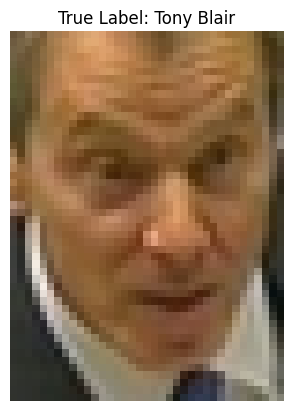

In [4]:
plt.imshow(images[0])
plt.title("True Label: " + target_names[y[0]])
plt.axis("off")
plt.show()

In [ ]:
## Train Test Split

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, img_train, img_test = train_test_split(
    X, y, images, test_size=0.25, random_state=42
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 1170
Testing Samples: 390


In [ ]:
## Train SVM Model

In [6]:
from sklearn.svm import SVC

model = SVC(kernel='linear', probability=True)

print("Training Started...")
model.fit(X_train, y_train)
print("Training Completed")

Training Started...
Training Completed


In [ ]:
## Calculate Accuracy

In [7]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.8307692307692308


In [ ]:
## True Label, Predicted Label, Confidence

In [8]:
import numpy as np

probabilities = model.predict_proba(X_test)

for i in range(5):
    confidence = np.max(probabilities[i])
    predicted_label = target_names[y_pred[i]]
    true_label = target_names[y_test[i]]

    print("True Label:", true_label)
    print("Predicted Label:", predicted_label)
    print("Confidence Level:", confidence)
    print("-"*40)

True Label: George W Bush
Predicted Label: George W Bush
Confidence Level: 0.9893420627201894
----------------------------------------
True Label: Colin Powell
Predicted Label: Colin Powell
Confidence Level: 0.9492981556625708
----------------------------------------
True Label: George W Bush
Predicted Label: George W Bush
Confidence Level: 0.7893904646904895
----------------------------------------
True Label: Tony Blair
Predicted Label: Tony Blair
Confidence Level: 0.7578341020731957
----------------------------------------
True Label: Colin Powell
Predicted Label: Colin Powell
Confidence Level: 0.8393728842677598
----------------------------------------


In [ ]:
## Ignore Low Confidence

In [9]:
threshold = 0.60

for i in range(5):
    confidence = np.max(probabilities[i])
    predicted_label = target_names[y_pred[i]]
    true_label = target_names[y_test[i]]

    if confidence < threshold:
        print("Low Confidence Prediction - Ignored")
    else:
        print("True Label:", true_label)
        print("Predicted Label:", predicted_label)
        print("Confidence:", confidence)
        print("-"*40)

True Label: George W Bush
Predicted Label: George W Bush
Confidence: 0.9893420627201894
----------------------------------------
True Label: Colin Powell
Predicted Label: Colin Powell
Confidence: 0.9492981556625708
----------------------------------------
True Label: George W Bush
Predicted Label: George W Bush
Confidence: 0.7893904646904895
----------------------------------------
True Label: Tony Blair
Predicted Label: Tony Blair
Confidence: 0.7578341020731957
----------------------------------------
True Label: Colin Powell
Predicted Label: Colin Powell
Confidence: 0.8393728842677598
----------------------------------------


In [10]:
print(img_test.shape)

(390, 50, 37, 3)


In [ ]:
## Random LFW Image Prediction + Show Rectangle + Name 

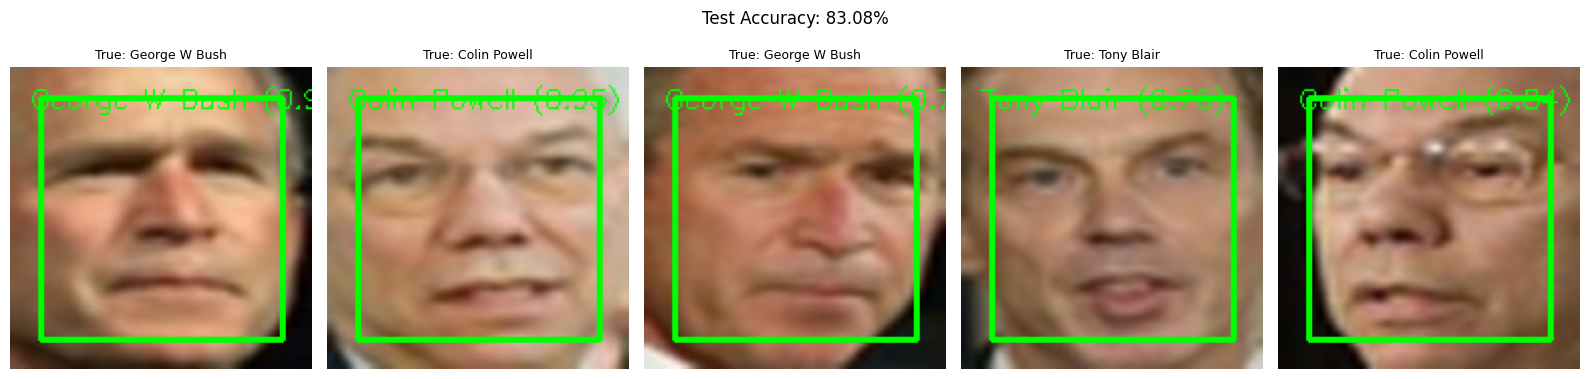

In [11]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
from sklearn.metrics import accuracy_score

num_images = 5

plt.figure(figsize=(16,4))

for i in range(num_images):

    img = img_test[i].copy()

    img = (img * 255).astype("uint8")

    img = cv2.resize(img, (150,150), interpolation=cv2.INTER_CUBIC)

    img_color = img.copy()

    # 🔹 Prediction info
    confidence = np.max(probabilities[i])
    predicted_label = target_names[y_pred[i]]
    true_label = target_names[y_test[i]]

    # 🔹 Green if correct, Red if wrong
    color = (0,255,0) if y_pred[i] == y_test[i] else (255,0,0)

    # 🔹 Draw rectangle (adjusted for 150x150 image)
    cv2.rectangle(img_color, (15,15), (135,135), color, 2)

    # 🔹 Put prediction text (moved slightly down for cleaner look)
    cv2.putText(img_color,
                f"{predicted_label} ({confidence:.2f})",
                (10,20),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.45,
                color,
                1)

    # 🔹 Plot image
    plt.subplot(1, num_images, i+1)
    plt.imshow(img_color)
    plt.title(f"True: {true_label}", fontsize=9)
    plt.axis("off")

# 🔥 Overall Accuracy
accuracy = accuracy_score(y_test, y_pred) * 100
plt.suptitle(f"Test Accuracy: {accuracy:.2f}%", fontsize=12)

plt.tight_layout()
plt.show()

In [12]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=target_names))

                   precision    recall  f1-score   support

     Ariel Sharon       0.76      0.81      0.79        16
     Colin Powell       0.81      0.94      0.87        66
  Donald Rumsfeld       0.65      0.74      0.69        27
    George W Bush       0.90      0.86      0.88       140
Gerhard Schroeder       0.67      0.75      0.71        24
      Hugo Chavez       0.92      0.71      0.80        17
   Jacques Chirac       1.00      0.60      0.75        10
    Jean Chretien       0.69      0.79      0.73        14
    John Ashcroft       0.92      0.75      0.83        16
Junichiro Koizumi       0.89      0.73      0.80        11
  Serena Williams       0.89      0.89      0.89         9
       Tony Blair       0.89      0.85      0.87        40

         accuracy                           0.83       390
        macro avg       0.83      0.78      0.80       390
     weighted avg       0.84      0.83      0.83       390



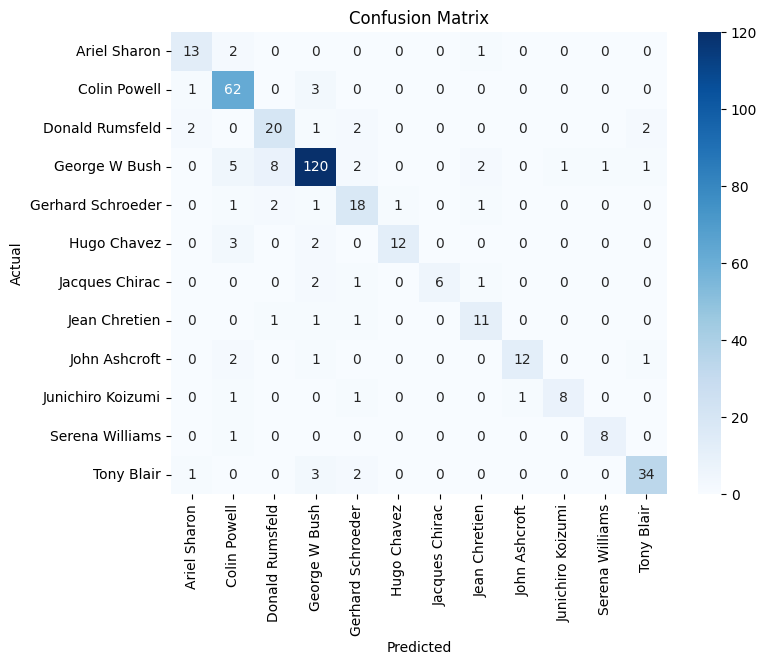

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names,
            yticklabels=target_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()